# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

# Read Image

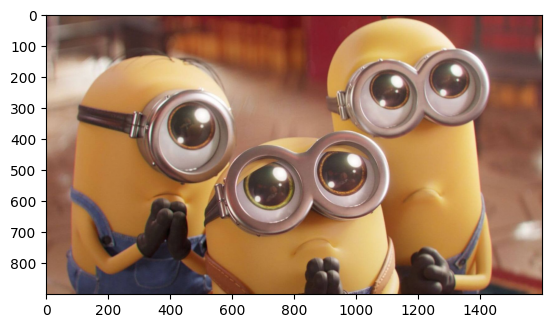

In [3]:
img = mpimg.imread('/content/drive/MyDrive/ML/computational data mining/تمرین پنجم/minion.jpg')

plt.imshow(img)

In [4]:
print(type(img))

<class 'numpy.ndarray'>


In [5]:
print('shape of image :', img.shape)

shape of image : (900, 1600, 3)


In [6]:
print(img.dtype)

uint8


# Adding Noise to Image

Gaussian Noise

In [7]:
# Adding Gaussian noise
mean, std_dev = 0, 25
gaussian_noise = np.random.normal(mean, std_dev, img.shape).astype(np.float32)
dst = cv2.add(img.astype(np.float32), gaussian_noise)

# Clip the resulting image to ensure valid pixel values
dst = np.clip(dst, 0, 255).astype(np.uint8)

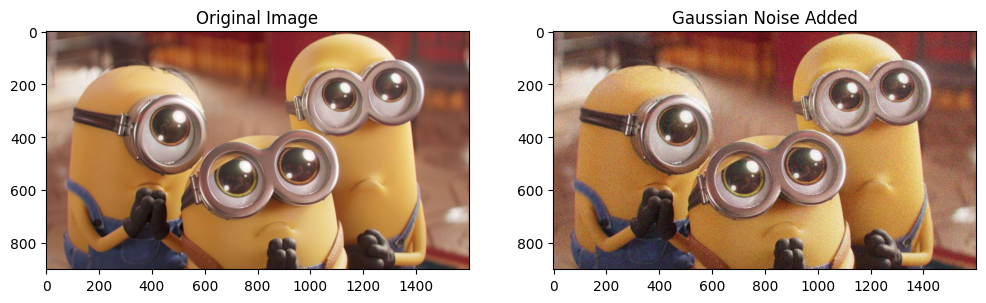

In [8]:
# Plotting the source and destination images
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(img), plt.title("Original Image")
plt.subplot(122), plt.imshow(dst), plt.title("Gaussian Noise Added")
plt.show()

# Singular Value Decomposition for grayscale image

In [9]:
X = np.mean(dst, -1); #convert RGB to Grayscale
print(X.shape) #to check the original image shape

(900, 1600)


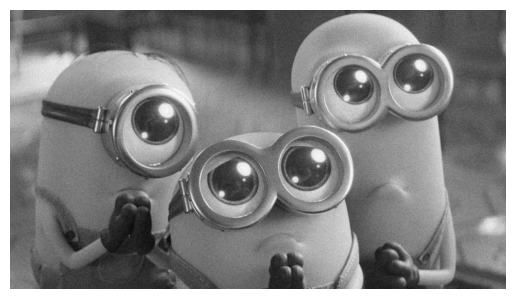

In [10]:
img = plt.imshow(X)
img.set_cmap('gray') #simply just changing the BG
plt.axis('off')
plt.show()

In [11]:
U, S, VT = np.linalg.svd(X, full_matrices = False) #camputuring the singular values and left and right singular vector

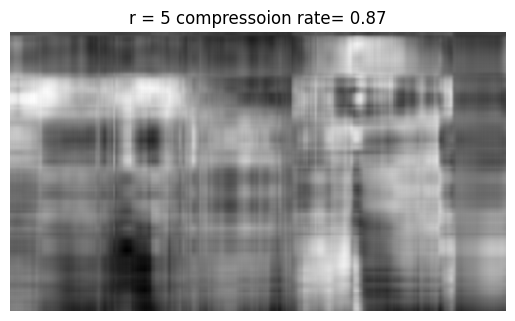

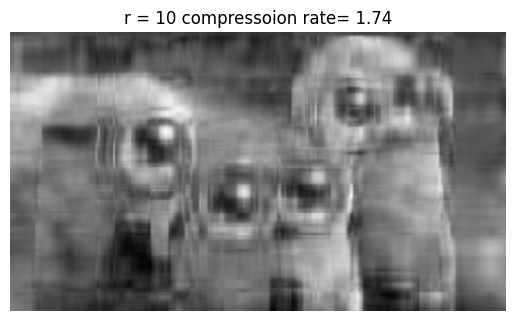

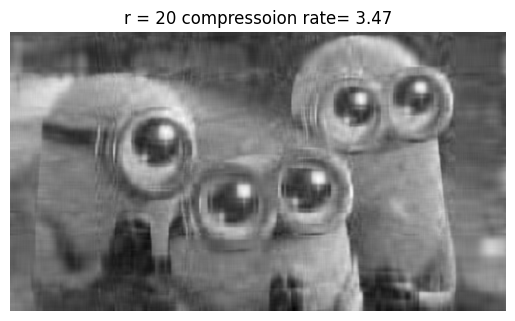

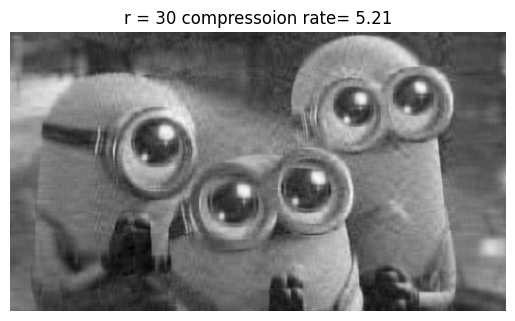

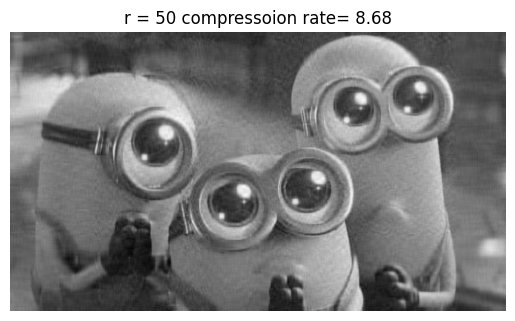

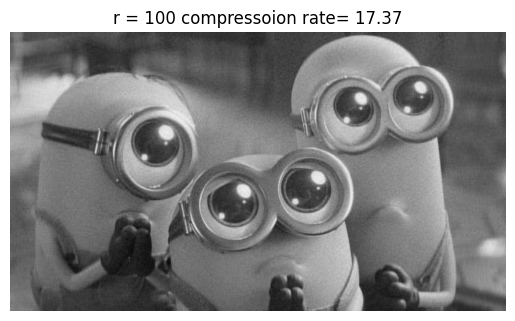

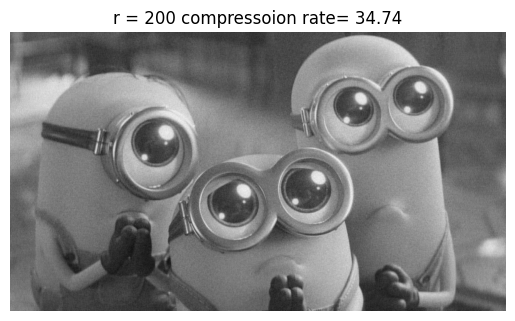

In [12]:
S = np.diag(S)

j = 0
row=900
col=1600

for r in (5, 10, 20, 30, 50, 100, 200):
    Xapprox = U[:, :r] @ S[0:r, :r] @ VT[:r, :]
    plt.figure(j+1)
    j += 1
    original_size = row*col
    compressedSize = r * (1 + row+col)
    compression_ratio = compressedSize*1.0/ original_size
    img = plt.imshow(Xapprox)
    plt.title('r = {} compressoion rate= {}'.format(r,round(compression_ratio*100,2)))
    img.set_cmap('gray')
    plt.axis('off')
    plt.show()

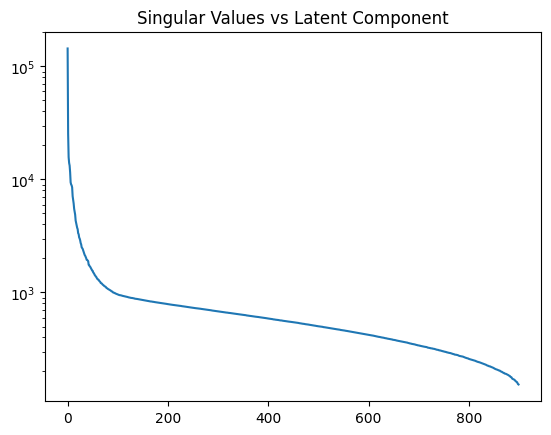

In [13]:
plt.figure(1)
plt.semilogy(np.diag(S))
plt.title('Singular Values vs Latent Component')
plt.show()

# Singular Value Decomposition for rgb image

Read Image

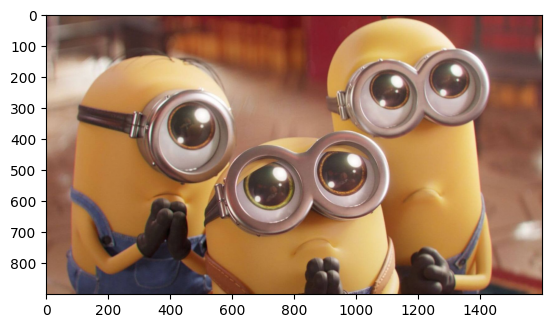

In [14]:
img = mpimg.imread('/content/drive/MyDrive/ML/computational data mining/تمرین پنجم/minion.jpg')

plt.imshow(img)

Adding Noise to an Image Using OpenCV

Gaussian Noise

In [15]:
# Adding Gaussian noise
mean, std_dev = 0, 25
gaussian_noise = np.random.normal(mean, std_dev, img.shape).astype(np.float32)
dst = cv2.add(img.astype(np.float32), gaussian_noise)

# Clip the resulting image to ensure valid pixel values
dst = np.clip(dst, 0, 255).astype(np.uint8)

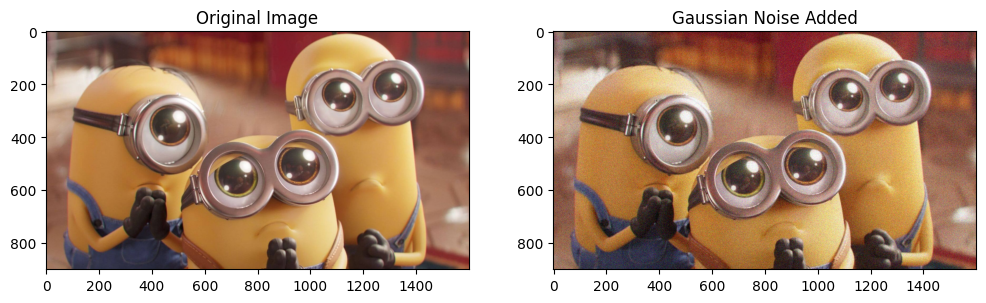

In [16]:
# Plotting the source and destination images
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(img), plt.title("Original Image")
plt.subplot(122), plt.imshow(dst), plt.title("Gaussian Noise Added")
plt.show()

In [17]:
img = dst.astype(np.float64) / 255.0

In [18]:
#3D image
#   ↓ slice
#3 × 2D matrices
#   ↓
#SVD works on each

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

In [19]:
U_R, S_R, VT_R = np.linalg.svd(R, full_matrices = False) #camputuring the singular values and left and right singular vector
U_G, S_G, VT_G = np.linalg.svd(G, full_matrices = False) #camputuring the singular values and left and right singular vector
U_B, S_B, VT_B = np.linalg.svd(B, full_matrices = False) #camputuring the singular values and left and right singular vector

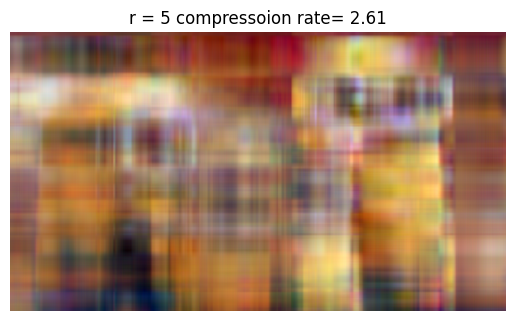

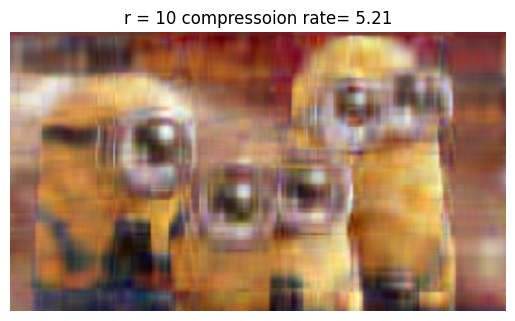

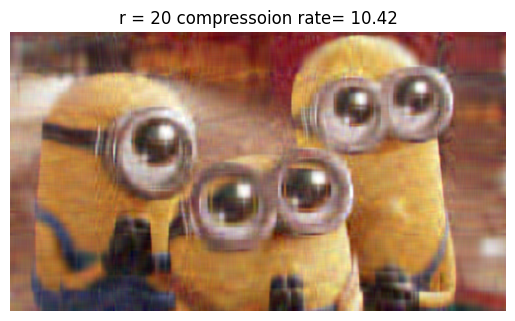

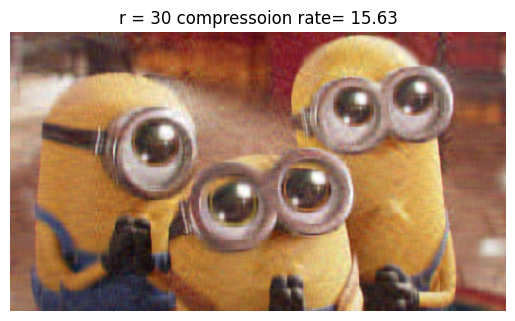

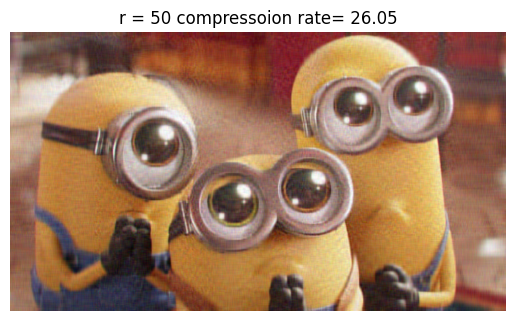

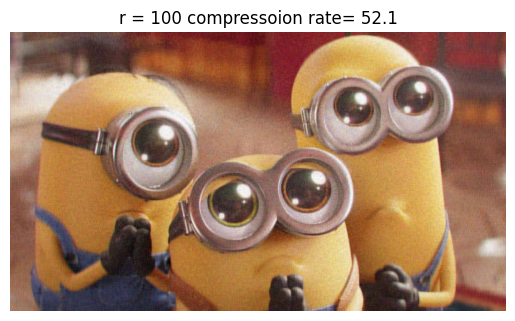

In [20]:
j = 0
row=900
col=1600

for r in (5, 10, 20, 30, 50, 100):

    R_r = U_R[:, :r] @ np.diag(S_R[:r]) @ VT_R[:r, :]
    G_r = U_G[:, :r] @ np.diag(S_G[:r]) @ VT_G[:r, :]
    B_r = U_B[:, :r] @ np.diag(S_B[:r]) @ VT_B[:r, :]

    img_r = np.stack((R_r, G_r, B_r), axis=2)

    plt.figure(j+1)
    j += 1
    original_size = row*col

    compressedSize = 3 * r * (1 + row+col)

    compression_ratio = compressedSize*1.0/ original_size
    img = plt.imshow(img_r)
    plt.title('r = {} compressoion rate= {}'.format(r,round(compression_ratio*100,2)))

    plt.axis('off')
    plt.show()

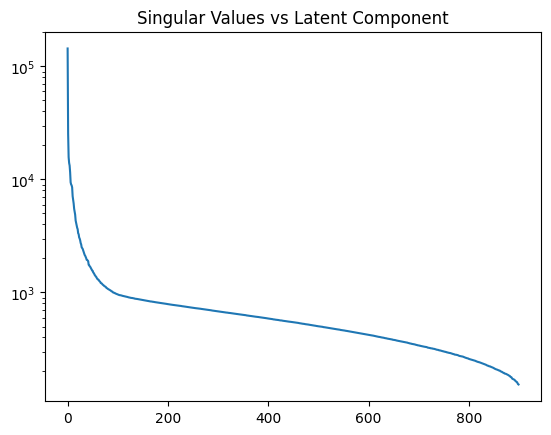

In [21]:
plt.figure(1)
plt.semilogy(np.diag(S))
plt.title('Singular Values vs Latent Component')
plt.show()